# Notebook 1 — Exploring the Speech Data (RAVDESS)

Before training any model, we need to understand our data.

In this notebook we will:
- Look at how many audio files we have per emotion
- Listen to some audio files
- Visualize what audio looks like as a wave
- Visualize what MFCC looks like (the numbers we feed into the model)


## Step 1 — Import Libraries

These are the tools we need. Think of them like importing different apps.

In [2]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import IPython.display as ipd

print('All libraries loaded!')

All libraries loaded!


## Step 2 — Load All Audio File Paths

We will scan the ravdess folder and collect all .wav file paths.
We will also read the emotion label from each filename.

In [3]:
# Emotion code from RAVDESS filename (position 3)
EMOTION_MAP = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': 'surprised'
}

# Our interview labels
INTERVIEW_MAP = {
    'neutral':   'Neutral',
    'calm':      'Neutral',
    'happy':     'Confident',
    'sad':       'Nervous',
    'angry':     'Nervous',
    'fearful':   'Nervous',
    'disgust':   'Confident',
    'surprised': 'Confident'
}

DATA_DIR = '../data/raw/ravdess'

file_paths = []
emotions = []
interview_labels = []

for root, dirs, files in os.walk(DATA_DIR):
    for file in files:
        if file.endswith('.wav'):
            parts = file.split('-')
            emotion_code = parts[2]
            emotion = EMOTION_MAP.get(emotion_code, 'unknown')
            interview_label = INTERVIEW_MAP.get(emotion, 'Neutral')
            
            file_paths.append(os.path.join(root, file))
            emotions.append(emotion)
            interview_labels.append(interview_label)

# Create a DataFrame (like an Excel table)
df = pd.DataFrame({
    'file_path': file_paths,
    'emotion': emotions,
    'interview_label': interview_labels
})

print(f'Total audio files found: {len(df)}')
print()
df.head(10)

Total audio files found: 2880



,file_path,emotion,interview_label
0,../data/raw/ravdess/Actor_16/03-01-05-01-02-01...,angry,Nervous
1,../data/raw/ravdess/Actor_16/03-01-06-01-02-02...,fearful,Nervous
2,../data/raw/ravdess/Actor_16/03-01-06-02-01-02...,fearful,Nervous
3,../data/raw/ravdess/Actor_16/03-01-05-02-01-01...,angry,Nervous
4,../data/raw/ravdess/Actor_16/03-01-07-01-01-01...,disgust,Confident
5,../data/raw/ravdess/Actor_16/03-01-04-01-01-02...,sad,Nervous
6,../data/raw/ravdess/Actor_16/03-01-04-02-02-02...,sad,Nervous
7,../data/raw/ravdess/Actor_16/03-01-07-02-02-01...,disgust,Confident
8,../data/raw/ravdess/Actor_16/03-01-08-02-02-01...,surprised,Confident
9,../data/raw/ravdess/Actor_16/03-01-08-01-01-01...,surprised,Confident


## Step 3 — How Many Files Per Emotion?

Let's count how many audio files we have for each emotion.

In [4]:
print('=== Files per Emotion ===')
print(df['emotion'].value_counts())
print()
print('=== Files per Interview Label ===')
print(df['interview_label'].value_counts())

=== Files per Emotion ===
emotion
angry        384
fearful      384
disgust      384
sad          384
surprised    384
happy        384
calm         384
neutral      192
Name: count, dtype: int64

=== Files per Interview Label ===
interview_label
Nervous      1152
Confident    1152
Neutral       576
Name: count, dtype: int64


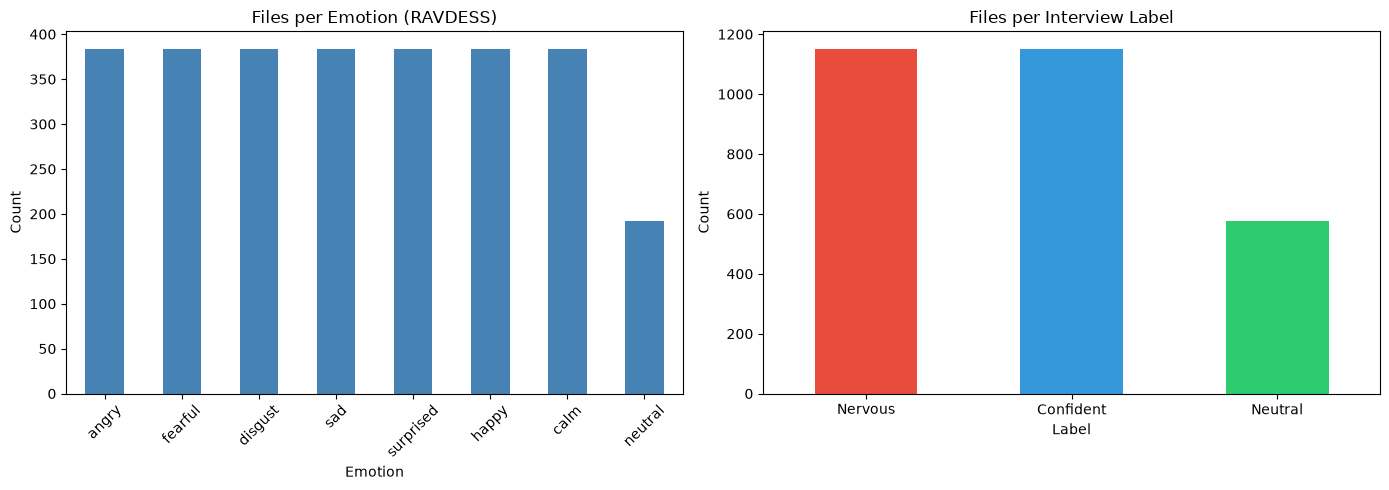

In [5]:
# Visualize as a bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original emotions
df['emotion'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Files per Emotion (RAVDESS)')
axes[0].set_xlabel('Emotion')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Interview labels
colors = ['#e74c3c', '#3498db', '#2ecc71']
df['interview_label'].value_counts().plot(kind='bar', ax=axes[1], color=colors)
axes[1].set_title('Files per Interview Label')
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## Step 4 — Listen to an Audio File

Let's actually listen to one of the audio files!

In [6]:
# Pick a HAPPY (Confident) audio file
happy_file = df[df['emotion'] == 'happy']['file_path'].iloc[0]
print(f'Playing: {os.path.basename(happy_file)}')
print('Label: Confident')
ipd.Audio(happy_file)

Playing: 03-01-03-02-02-02-16.wav
Label: Confident


In [7]:
# Pick a FEARFUL (Nervous) audio file
fearful_file = df[df['emotion'] == 'fearful']['file_path'].iloc[0]
print(f'Playing: {os.path.basename(fearful_file)}')
print('Label: Nervous')
ipd.Audio(fearful_file)

Playing: 03-01-06-01-02-02-16.wav
Label: Nervous


## Step 5 — Visualize Audio as a Wave

This is what audio looks like when converted to numbers — a wave.
The x-axis is time, the y-axis is loudness.

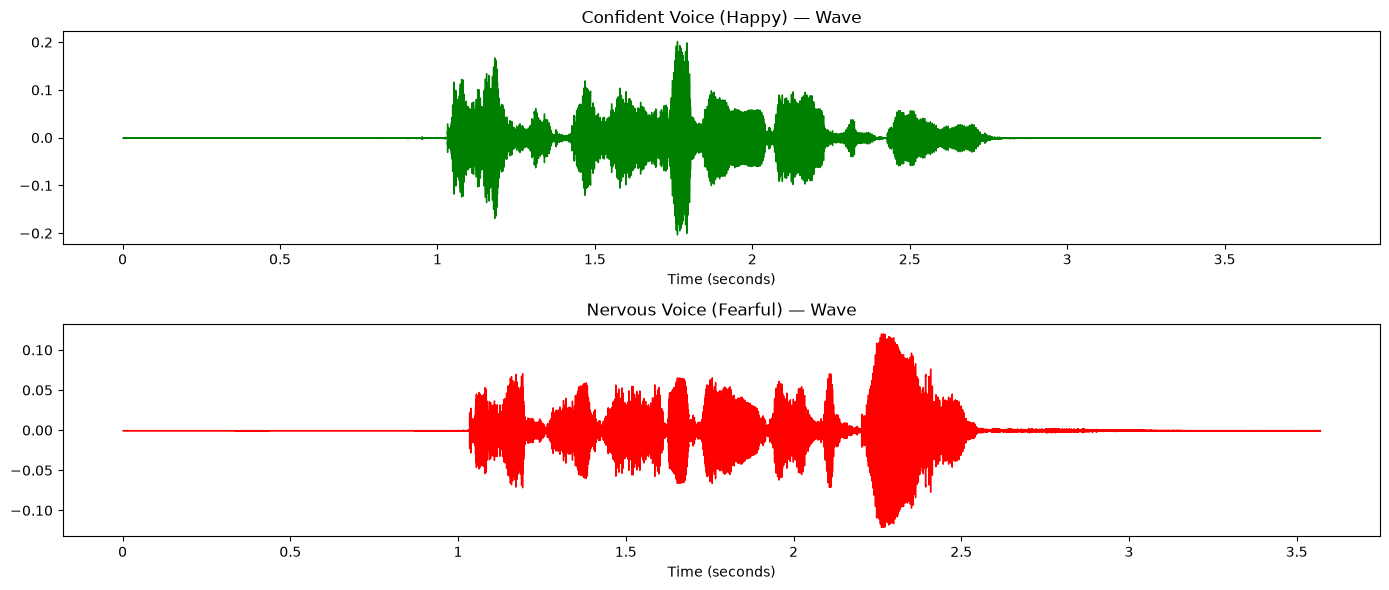

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6))

# Load and plot happy audio
audio_happy, sr = librosa.load(happy_file)
librosa.display.waveshow(audio_happy, sr=sr, ax=axes[0], color='green')
axes[0].set_title('Confident Voice (Happy) — Wave')
axes[0].set_xlabel('Time (seconds)')

# Load and plot fearful audio
audio_fearful, sr = librosa.load(fearful_file)
librosa.display.waveshow(audio_fearful, sr=sr, ax=axes[1], color='red')
axes[1].set_title('Nervous Voice (Fearful) — Wave')
axes[1].set_xlabel('Time (seconds)')

plt.tight_layout()
plt.show()

## Step 6 — Visualize MFCC

MFCC converts the audio wave into a 2D grid of numbers.
This is what we actually feed into the model.
Think of it like converting sound into an image the model can read.

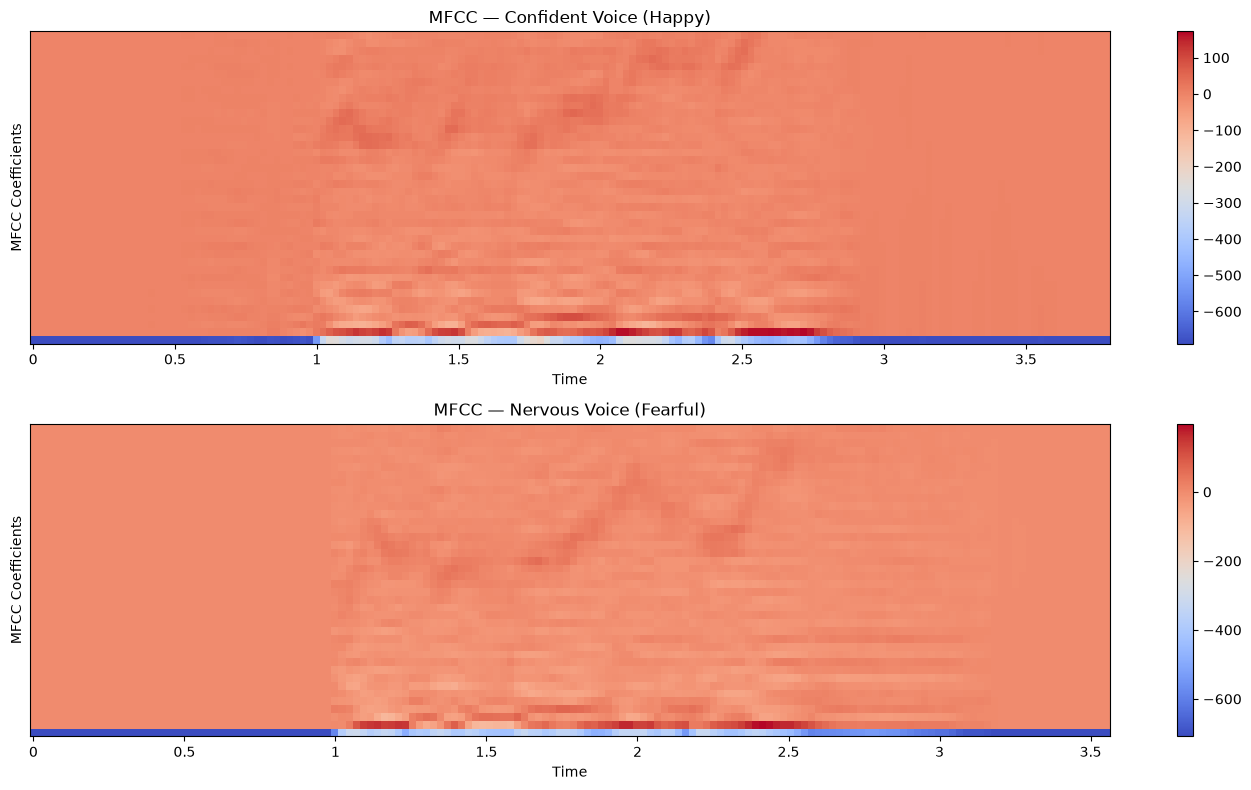

MFCC shape for one audio file: (40, 164)
This means: 40 coefficients x time steps
This grid of numbers is what the model learns from!


In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# MFCC for confident voice
mfcc_happy = librosa.feature.mfcc(y=audio_happy, sr=sr, n_mfcc=40)
img1 = librosa.display.specshow(mfcc_happy, sr=sr, x_axis='time', ax=axes[0], cmap='coolwarm')
axes[0].set_title('MFCC — Confident Voice (Happy)')
axes[0].set_ylabel('MFCC Coefficients')
fig.colorbar(img1, ax=axes[0])

# MFCC for nervous voice
mfcc_fearful = librosa.feature.mfcc(y=audio_fearful, sr=sr, n_mfcc=40)
img2 = librosa.display.specshow(mfcc_fearful, sr=sr, x_axis='time', ax=axes[1], cmap='coolwarm')
axes[1].set_title('MFCC — Nervous Voice (Fearful)')
axes[1].set_ylabel('MFCC Coefficients')
fig.colorbar(img2, ax=axes[1])

plt.tight_layout()
plt.show()

print(f'MFCC shape for one audio file: {mfcc_happy.shape}')
print('This means: 40 coefficients x time steps')
print('This grid of numbers is what the model learns from!')

## Summary

What we learned in this notebook:
- We have 2,880 audio files total
- Each file is labeled with an emotion
- We group them into 3 interview labels: Confident, Nervous, Neutral
- Audio is converted to MFCC (a grid of numbers) before feeding to the model
- The model will learn the difference between confident and nervous MFCC patterns

Next notebook: We process ALL audio files into MFCC and train the speech model!